In [1]:
from src.backend import TorchBackend
from src.kvector import compute_k0xy, compute_Kxy
from src.geometry import Rectangle, Bitmap, Canvas
from src.layer import MaterialMap

from tests.backend import test_torch_backend_full
from tests.kvector import test_k0xy_full, test_Kxy_full
from tests.geometry import run_all_geometry_tests
import torch

import matplotlib.pyplot as plt
test_k0xy_full()
test_Kxy_full()
run_all_geometry_tests()

✓ full kvector test passed.
✓ full Kxy test passed.
FFT vs analytic RMSE: 0.0006081252346614848
All geometry tests passed.


RMSE between FFT and Fourier coefficients: 0.001196236816478475


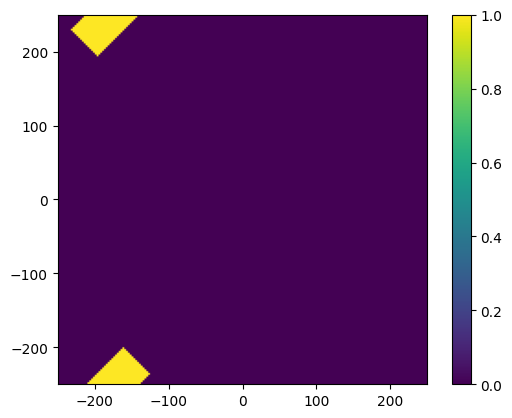

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
backend = TorchBackend(device=device, dtype=dtype)

period = (500.0, 500.0)
grid = (201, 201)
canv = Canvas(period, grid)
MN = (1, 1)
epsilon = backend.asarray(torch.tensor([2, 3, 4, 5]) + 0.1j, complex=True)  # (B,)
rect = Rectangle(backend, 
                 canvas=canv,
                 center=(-180, 245), 
                 size=(100, 50), 
                 epsilon=epsilon, 
                 angle=45.0*torch.pi/180)

epsilon_xy = rect.epsilon_xy(epsilonbg=1.0)
epsilon_mn = rect.epsilon_mn(M=MN[0], N=MN[1], epsilonbg=1.0).cpu()

# epsilon_xy = rect.matdist_real(period, grid, matbg=1.0, backend=backend).cpu()
# epsilon_mn = rect.matdist_fourier(period, M=21, N=21, matbg=1.0, backend=backend).cpu()

plt.imshow(rect.bitmap.cpu().T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.colorbar()
# plt.xlim(-75, 75)
# plt.ylim(-75, 75)

# 1. FFT and normalization
fft_xy = torch.fft.fft2(epsilon_xy.cpu(), dim=(-2, -1)) / (grid[0] * grid[1])   # (B, Nx, Ny)

# 2. Shift zero-frequency to center (to match your epsilon_mn indexing)
fft_xy_shift = torch.fft.fftshift(fft_xy, dim=(-2, -1))         # (B, Nx, Ny)

# 3. Crop central (2M+1, 2N+1) block
cx = grid[0] // 2
cy = grid[1] // 2
m_lo = cx - MN[0]
m_hi = cx + MN[0] + 1
n_lo = cy - MN[1]
n_hi = cy + MN[1] + 1

fft_xy_crop = fft_xy_shift[:, m_lo:m_hi, n_lo:n_hi]             # (B, 2M+1, 2N+1)

# 4. Now compare cropped FFT with epsilon_mn directly
rmse = torch.sqrt(torch.mean(torch.abs(fft_xy_crop - epsilon_mn) ** 2))
print(f"RMSE between FFT and Fourier coefficients: {rmse.item()}")

Numeric: tensor([[0.0110+0.0142j, 0.0111+0.0163j, 0.0101+0.0171j],
        [0.0197+0.0007j, 1.0205+0.0020j, 0.0195+0.0032j],
        [0.0133-0.0148j, 0.0141-0.0138j, 0.0136-0.0117j]],
       dtype=torch.complex128)
Analytic: tensor([[0.0107+0.0139j, 0.0108+0.0160j, 0.0098+0.0168j],
        [0.0193+0.0007j, 1.0200+0.0020j, 0.0190+0.0031j],
        [0.0129-0.0145j, 0.0137-0.0136j, 0.0132-0.0115j]],
       dtype=torch.complex128)


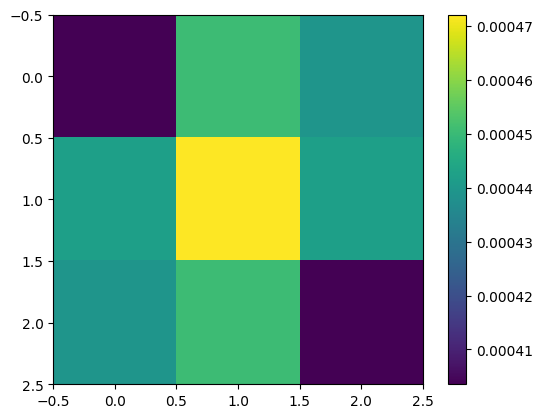

In [10]:
plt.imshow(abs(epsilon_mn[0] - fft_xy_crop[0]))
plt.colorbar()

print(f"Numeric: {(fft_xy_crop[0])}")
print(f"Analytic: {(epsilon_mn[0])}")

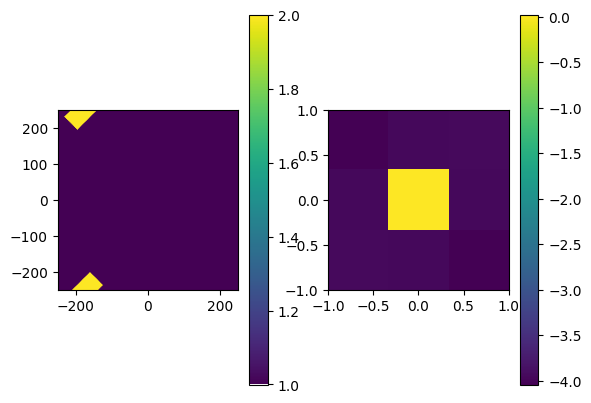

In [11]:
plt.subplot(1, 2, 1)
plt.imshow(epsilon_xy[0].real.cpu().T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(torch.log(torch.abs(epsilon_mn[0])).cpu(), extent=(-MN[0], MN[0], -MN[1], MN[1]))
plt.colorbar()

In [20]:
bitmap_im = rect.bitmap.cpu()

bitmap = Bitmap(backend, 
                canv, 
                bitmap=bitmap_im, 
                epsilon_value=epsilon, 
                epsilon_bg=1.0)

bitmap.epsilon_xy.shape

torch.Size([4, 201, 201])

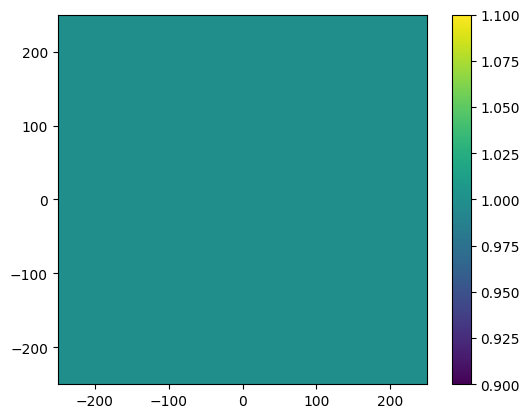

In [26]:
plt.imshow(bitmap.mu_xy[0].real.T.cpu(), origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.colorbar()

In [82]:
print(f"{abs(epsilon_mn[0] - fft_xy_crop[0])}")

tensor([[2.4591e-04, 1.6734e-02, 6.4495e-07],
        [1.6734e-02, 0.0000e+00, 1.6734e-02],
        [6.4578e-07, 1.6734e-02, 2.4591e-04]])


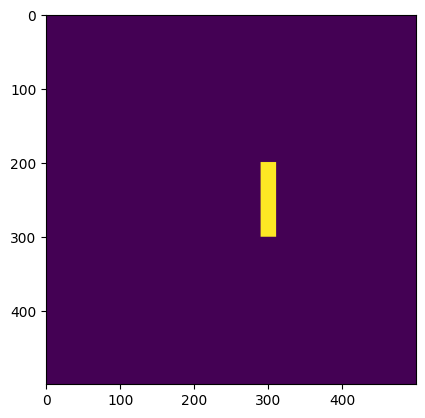

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
backend = TorchBackend(device=device, dtype=dtype)

period = (500.0, 500.0)
grid = (500, 500)

epsilon = backend.asarray(torch.tensor([2, 3, 4, 5]) + 0.1j, complex=True)  # (B,)
rect1 = Rectangle(backend, center=(50, 0), size=(20, 100), epsilon=epsilon)

plt.imshow(rect1.to_bitmap(period, grid).cpu().T)